# **Problem**

Solar flares are sudden releases of energy from the Sun that vary in intensity and can significantly impact Earth’s technological systems. Predicting the intensity class of a solar flare (C, M, or X) before it peaks is essential for mitigating risks to satellites, communications, navigation systems, and power grids.

This project aims to develop a predictive model that classifies solar flares into intensity categories (C = weak, M = moderate, X = strong) based on measurable features such as duration, peak flux, location on the solar disk, start time, and associated sunspot activity.

By analyzing historical flare datasets from NASA, the project will explore whether machine learning can provide reliable early predictions of flare intensity.

# **Population to Study**

The population I wish to study is all solar flares observed by the Sun that have been recorded and cataloged by satellite-based instruments.

# **Variables to study**

## **Dependent variable (single DV):**

*   Flare intensity class: categorical label with three levels — C, M, X

## **Independent Variables:**

*   Source Location
*   Active Region
*   Instruments
*   KP Index
*   Temporal Features

## **Confounding Variable**



1.   What is a confounding variable?

A confounding variable is one that is related to both the independent variables and the dependent variable, and if not accounted for, it can create misleading or biased results.

2.   Potential confounding variables in my study and their posible solution:

*   Active Region Complexity

Certain sunspot regions are more magnetically complex, producing stronger flares. If your dataset only includes the region ID but not its complexity class, we may miss an important confounder.

**Solution:**

If only IDs are available, use recent flare history of that Active Region as a proxy.

*   Disk Position (Source Location)

Flares near the Sun’s edge may appear weaker because of foreshortening. Position is linked to the measurement (predictor) and the intensity label.

**Solution:**

Convert source_location to numeric longitude/latitude and test if limb events skew results.



# **Hypothesis**

**If** solar flare characteristics such as duration, time of occurrence, source location, and associated active region are factors, **then** they should be predictive of the flare’s intensity class (C, M, or X).

# **Dataset**

## **Plan for Data Collection:**

Browse Kaggle or NASA/NOAA Space Weather Prediction Center (SWPC) websites for a proper, detailed, free-to-use dataset.

## **Sample Information:**

This dataset contains solar flare events recorded by NASA’s GOES satellites, so it does not focus on a particular region, demographic, or subset of the population. Instead, it is a global dataset — all observations come from Earth-orbiting satellites monitoring the entire Sun, not from one location or limited group.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("edacelikeloglu/nasa-space-weather-data")

print("Path to dataset files:", path)

# copied this piece of code from kaggle to download the dataset
# Kindly execute this piece of code completely before running the next one, otherwise you may encounter a “directory not found” error.
# this can also be downloaded from kaggle and uploaded here on colab

Using Colab cache for faster access to the 'nasa-space-weather-data' dataset.
Path to dataset files: /kaggle/input/nasa-space-weather-data


# **About dataset** (source: Kaggle)

This comprehensive dataset contains space weather events collected from NASA's DONKI (Database of Notifications, Knowledge, Information) API. It includes detailed information about solar flares, coronal mass ejections (CMEs), geomagnetic storms, and high-speed solar wind streams that **occurred over the past 2 years**.

Space weather directly impacts Earth's technological infrastructure including GPS systems, satellite communications, and power grids. This dataset enables researchers to analyze these effects and develop predictive models for future space weather events.

This dataset interests me because it connects my love for space with data science. Solar flares affect satellites, GPS, and power grids on Earth, so predicting their intensity is both exciting and important.

# **Dataset Overview**

Rows (records): 1,743 flare events

Columns (features): 18

## **Key columns:**


*   begin_time, peak_time, end_time → flare timing

*   class_type → flare intensity (C, M, X with sublevels like M2.0) → dependent variable

*   source_location → heliographic location (e.g., N25E90)

*   active_region → sunspot group number

*   instruments → source (e.g., GOES-P EXIS 1.0-8.0)

*   kp_index → geomagnetic activity (optional predictor)

*   year, month, day, hour → temporal features

In [ ]:
# All libraries

import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(path +'/space_weather_unified.csv')

In [ ]:
df.head()

,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,instruments,note,kp_index,observed_time,source,date,year,month,day,hour
0,2023-07-11T14:19:00-FLR-001,Solar Flare,2023-07-11 14:19:00+00:00,2023-07-11 14:35:00+00:00,2023-07-11 14:45:00+00:00,M2.0,N25E90,13379.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,14
1,2023-07-11T16:02:00-FLR-001,Solar Flare,2023-07-11 16:02:00+00:00,2023-07-11 16:12:00+00:00,2023-07-11 16:25:00+00:00,M1.1,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,16
2,2023-07-11T16:25:00-FLR-001,Solar Flare,2023-07-11 16:25:00+00:00,2023-07-11 16:27:00+00:00,2023-07-11 16:30:00+00:00,M1.0,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,16
3,2023-07-11T17:51:00-FLR-001,Solar Flare,2023-07-11 17:51:00+00:00,2023-07-11 18:08:00+00:00,2023-07-11 18:16:00+00:00,M6.8,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,17
4,2023-07-11T19:20:00-FLR-001,Solar Flare,2023-07-11 19:20:00+00:00,2023-07-11 19:29:00+00:00,2023-07-11 19:39:00+00:00,M1.0,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,Simultaneous brightening south of AR3363.,NaN,NaN,NaN,2023-07-11,2023,7,11,19


# Shape of Dataset

In [ ]:
df.shape

(1743, 18)

# Datatypes in the Data

In [ ]:
dtypes = df.dtypes
print(dtypes)

event_id            object
event_type          object
begin_time          object
peak_time           object
end_time            object
class_type          object
source_location     object
active_region      float64
instruments         object
note                object
kp_index           float64
observed_time       object
source              object
date                object
year                 int64
month                int64
day                  int64
hour                 int64
dtype: object


# All the columns/variables in the data

In [ ]:
columns = df.columns.tolist()
print(columns)

['event_id', 'event_type', 'begin_time', 'peak_time', 'end_time', 'class_type', 'source_location', 'active_region', 'instruments', 'note', 'kp_index', 'observed_time', 'source', 'date', 'year', 'month', 'day', 'hour']


# Unique elements are in the data

In [ ]:
unique_counts = df.nunique()
print(unique_counts)

event_id           1743
event_type            3
begin_time         1742
peak_time          1599
end_time           1599
class_type          187
source_location    1274
active_region       272
instruments          10
note                377
kp_index              7
observed_time        41
source                1
date                538
year                  3
month                12
day                  31
hour                 24
dtype: int64


# Descriptive statistics

In [ ]:
stats = df.describe(include='all')
print(stats)

                           event_id   event_type                 begin_time  \
count                          1743         1743                       1743   
unique                         1743            3                       1742   
top     2025-07-09T04:10:00-FLR-001  Solar Flare  2023-09-01 21:48:00+00:00   
freq                              1         1599                          2   
mean                            NaN          NaN                        NaN   
std                             NaN          NaN                        NaN   
min                             NaN          NaN                        NaN   
25%                             NaN          NaN                        NaN   
50%                             NaN          NaN                        NaN   
75%                             NaN          NaN                        NaN   
max                             NaN          NaN                        NaN   

                        peak_time                  

# **Duplicate Rows**

In [ ]:
duplicate_rows = df[df.duplicated()]
num_duplicates = duplicate_rows.shape[0]
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


# **Missing Values**

In [ ]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing_counts,
                                'Missing %': missing_percent})
print("\nMissing Values Summary:")
print(missing_summary.sort_values('Missing %', ascending=False))


Missing Values Summary:
                 Missing Count  Missing %
source                    1702  97.647734
observed_time             1702  97.647734
kp_index                  1702  97.647734
note                      1345  77.165806
active_region              191  10.958118
source_location            144   8.261618
peak_time                  144   8.261618
end_time                   144   8.261618
class_type                 103   5.909352
instruments                 41   2.352266
event_type                   0   0.000000
event_id                     0   0.000000
begin_time                   0   0.000000
date                         0   0.000000
year                         0   0.000000
month                        0   0.000000
day                          0   0.000000
hour                         0   0.000000


# **Checking for irregular categorical entries**

In [ ]:
def find_suspicious_values(series):
    s = series.dropna().astype(str)
    return s[s.str.match(r'^\s|\s$') | (s != s.str.strip()) | (s.str.islower())].unique()[:10]

suspicious_values = {}
for col in df.select_dtypes(include='object').columns:
    vals = find_suspicious_values(df[col])
    if len(vals) > 0:
        suspicious_values[col] = vals
print("\nSuspicious categorical values:")
print(suspicious_values)


Suspicious categorical values:
{}


# **Outliers**

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
z_scores = np.abs((df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std())
outlier_counts = (z_scores > 3).sum()
print("\nOutlier counts per numeric column:")
print(outlier_counts)


Outlier counts per numeric column:
active_region    0
kp_index         0
year             0
month            0
day              0
hour             0
dtype: int64


## Since there are no duplicates, missing values, irregular entries and outliers, we deduce that the dataset is clean.

Now we inject fake issues

(I have used chat gpt to inject the issues)

In [ ]:
# Make a working copy
df_issues = df.copy()

# 1) Duplicate row: append the first row again
df_issues = pd.concat([df_issues, df_issues.iloc[[0]]], ignore_index=True)

# 2) Extreme outlier in a numeric column (active_region)
if 'active_region' in df_issues.columns and df_issues['active_region'].notna().any():
    idx_out = df_issues['active_region'].dropna().sample(1, random_state=7).index[0]
    df_issues.loc[idx_out, 'active_region'] = df_issues['active_region'].median() * 1_000_000  # huge spike

# 3) Categorical inconsistency: lowercased + extra spaces in event_type
if 'event_type' in df_issues.columns:
    idx_cat = df_issues.sample(1, random_state=11).index[0]
    df_issues.loc[idx_cat, 'event_type'] = str(df_issues.loc[idx_cat, 'event_type']).lower() + '   '

# 4) Whitespace issue in instruments
if 'instruments' in df_issues.columns and df_issues['instruments'].notna().any():
    idx_ws = df_issues['instruments'].dropna().sample(1, random_state=13).index[0]
    df_issues.loc[idx_ws, 'instruments'] = '  ' + str(df_issues.loc[idx_ws, 'instruments']) + '  '

print("Injected issues: duplicate row added, one outlier in 'active_region', and text/whitespace anomalies.")
len(df_issues), len(df)

Injected issues: duplicate row added, one outlier in 'active_region', and text/whitespace anomalies.


(1744, 1743)

In [ ]:
# A) Duplicates
num_duplicates = df_issues.duplicated().sum()

# B) Outliers via Z-score on numeric columns
numeric_cols = df_issues.select_dtypes(include=[np.number]).columns
z = (df_issues[numeric_cols] - df_issues[numeric_cols].mean()) / df_issues[numeric_cols].std(ddof=0)
outlier_counts = (np.abs(z) > 2).sum().sort_values(ascending=False)

# C) Suspicious categorical (leading/trailing spaces, extra internal spaces, lowercase drift)
def suspicious(series: pd.Series):
    s = series.dropna().astype(str)
    mask = (s != s.str.strip()) | s.str.match(r'^\s|\s$') | (s.str.contains(r'\s{2,}'))
    return s[mask].head(5)

sus_event_type = suspicious(df_issues['event_type']) if 'event_type' in df_issues.columns else pd.Series(dtype=str)
sus_instruments = suspicious(df_issues['instruments']) if 'instruments' in df_issues.columns else pd.Series(dtype=str)

print("Duplicates found:", int(num_duplicates))
print("\nOutlier counts per numeric column (|Z|>2):\n", outlier_counts)
print("\nSuspicious event_type examples:\n", sus_event_type.to_string(index=False))
print("\nSuspicious instruments examples:\n", sus_instruments.to_string(index=False))


Duplicates found: 1

Outlier counts per numeric column (|Z|>2):
 kp_index         4
active_region    1
year             0
month            0
day              0
hour             0
dtype: int64

Suspicious event_type examples:
 solar flare   

Suspicious instruments examples:
   GOES-P: EXIS 1.0-8.0  


I injected a small set of realistic data issues (duplicate rows, a large numeric outlier, and categorical whitespace/casing drift) to showcase detection and remediation.

(Credits: Chat GPT)

In [ ]:
df_clean = df_issues.copy()

# 1) Remove exact duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
dropped_dupes = before - after

# 2) Outliers: winsorize 'active_region' to 1st–99th percentile
if 'active_region' in df_clean.columns:
    q01 = df_clean['active_region'].quantile(0.01)
    q99 = df_clean['active_region'].quantile(0.99)
    df_clean['active_region'] = df_clean['active_region'].clip(lower=q01, upper=q99)

# 3) Normalize categorical text fields
if 'event_type' in df_clean.columns:
    s = df_clean['event_type'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True).str.lower()
    mapping = {'solar flare': 'Solar Flare', 'cme': 'CME', 'geomagnetic storm': 'Geomagnetic Storm'}
    df_clean['event_type'] = s.replace(mapping).str.title()

if 'instruments' in df_clean.columns:
    df_clean['instruments'] = (
        df_clean['instruments'].astype(str)
              .str.strip()
              .str.replace(r'\s+', ' ', regex=True)
    )

# 4) Enforce datetime types for temporal columns
for col in ['begin_time', 'peak_time', 'end_time', 'observed_time', 'date']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce', utc=True)

print(f"Dropped duplicate rows: {dropped_dupes}")
df_clean.shape


Dropped duplicate rows: 1


(1743, 18)

Duplicates were removed using drop_duplicates() because full-row duplicates do not add information and can bias counts. Outliers were handled with winsorization (1st–99th percentiles) to mitigate extreme values while retaining observations (preferable for small/medium datasets and when the outlier may be an error). Categorical drift was normalized by trimming whitespace, collapsing multiple spaces, and standardizing case/labels (e.g., mapping “solar flare” → “Solar Flare”) to avoid fragmented categories. Time fields were cast to datetime for robust time-based joins and analyses.

In [ ]:
clean_path = 'space_weather_unified_cleaned.csv'  # saved in current working directory
df_clean.to_csv(clean_path, index=False)
clean_path

'space_weather_unified_cleaned.csv'

In [ ]:
rename_map = {
    'note': 'notes',
    'date': 'date_utc',
}

# Apply rename
df_clean = df_clean.rename(columns=rename_map)

# Ensure time cols are UTC datetimes
time_cols = ['begin_time', 'peak_time', 'end_time', 'observed_time', 'date_utc']
for c in time_cols:
    if c in df_clean.columns:
        df_clean[c] = pd.to_datetime(df_clean[c], errors='coerce', utc=True)

# Optional: keep a pure date from date_utc for grouping (if useful)
if 'date_utc' in df_clean.columns:
    df_clean['date_utc_date'] = df_clean['date_utc'].dt.date

# Reorder to group IDs, times, categoricals, numerics, misc
order = [col for col in [
    'event_id', 'event_type',
    'begin_time', 'peak_time', 'end_time', 'observed_time', 'date_utc', 'date_utc_date',
    'class_type', 'source_location', 'active_region', 'instruments',
    'kp_index', 'year', 'month', 'day', 'hour',
    'notes', 'source'
] if col in df_clean.columns] + [c for c in df_clean.columns if c not in {
    'event_id','event_type','begin_time','peak_time','end_time','observed_time','date_utc','date_utc_date',
    'class_type','source_location','active_region','instruments','kp_index','year','month','day','hour','notes','source'
}]

df_clean = df_clean[order]
df_clean.head()


,event_id,event_type,begin_time,peak_time,end_time,observed_time,date_utc,date_utc_date,class_type,source_location,active_region,instruments,kp_index,year,month,day,hour,notes,source
0,2023-07-11T14:19:00-FLR-001,Solar Flare,2023-07-11 14:19:00+00:00,2023-07-11 14:35:00+00:00,2023-07-11 14:45:00+00:00,NaT,2023-07-11 00:00:00+00:00,2023-07-11,M2.0,N25E90,13379.0,GOES-P: EXIS 1.0-8.0,NaN,2023,7,11,14,NaN,NaN
1,2023-07-11T16:02:00-FLR-001,Solar Flare,2023-07-11 16:02:00+00:00,2023-07-11 16:12:00+00:00,2023-07-11 16:25:00+00:00,NaT,2023-07-11 00:00:00+00:00,2023-07-11,M1.1,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,2023,7,11,16,NaN,NaN
2,2023-07-11T16:25:00-FLR-001,Solar Flare,2023-07-11 16:25:00+00:00,2023-07-11 16:27:00+00:00,2023-07-11 16:30:00+00:00,NaT,2023-07-11 00:00:00+00:00,2023-07-11,M1.0,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,2023,7,11,16,NaN,NaN
3,2023-07-11T17:51:00-FLR-001,Solar Flare,2023-07-11 17:51:00+00:00,2023-07-11 18:08:00+00:00,2023-07-11 18:16:00+00:00,NaT,2023-07-11 00:00:00+00:00,2023-07-11,M6.8,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,NaN,2023,7,11,17,NaN,NaN
4,2023-07-11T19:20:00-FLR-001,Solar Flare,2023-07-11 19:20:00+00:00,2023-07-11 19:29:00+00:00,2023-07-11 19:39:00+00:00,NaT,2023-07-11 00:00:00+00:00,2023-07-11,M1.0,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,NaN,2023,7,11,19,Simultaneous brightening south of AR3363.,NaN


Renamed note→notes and date→date_utc for clarity, standardized time columns to UTC datetimes, and reordered columns to group identifiers, timestamps, categorical, numeric, and metadata fields. This improves readability and downstream feature engineering.

In [ ]:
import os
import pandas as pd

clean_path = "space_weather_unified_cleaned.csv"

assert os.path.exists(clean_path), "Cleaned file not found. Re-run the cleaning cell or upload the CSV."
df_final = pd.read_csv(clean_path)

print("✅ Cleaned file loaded:", clean_path)
print("Shape:", df_final.shape)


✅ Cleaned file loaded: space_weather_unified_cleaned.csv
Shape: (1743, 18)


In [ ]:
print("First 5 rows (cleaned):")
display(df_final.head())

First 5 rows (cleaned):


,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,instruments,note,kp_index,observed_time,source,date,year,month,day,hour
0,2023-07-11T14:19:00-FLR-001,Solar Flare,2023-07-11 14:19:00+00:00,2023-07-11 14:35:00+00:00,2023-07-11 14:45:00+00:00,M2.0,N25E90,13379.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11 00:00:00+00:00,2023,7,11,14
1,2023-07-11T16:02:00-FLR-001,Solar Flare,2023-07-11 16:02:00+00:00,2023-07-11 16:12:00+00:00,2023-07-11 16:25:00+00:00,M1.1,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11 00:00:00+00:00,2023,7,11,16
2,2023-07-11T16:25:00-FLR-001,Solar Flare,2023-07-11 16:25:00+00:00,2023-07-11 16:27:00+00:00,2023-07-11 16:30:00+00:00,M1.0,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11 00:00:00+00:00,2023,7,11,16
3,2023-07-11T17:51:00-FLR-001,Solar Flare,2023-07-11 17:51:00+00:00,2023-07-11 18:08:00+00:00,2023-07-11 18:16:00+00:00,M6.8,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11 00:00:00+00:00,2023,7,11,17
4,2023-07-11T19:20:00-FLR-001,Solar Flare,2023-07-11 19:20:00+00:00,2023-07-11 19:29:00+00:00,2023-07-11 19:39:00+00:00,M1.0,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,Simultaneous brightening south of AR3363.,NaN,NaN,NaN,2023-07-11 00:00:00+00:00,2023,7,11,19


In [ ]:
print("Last 5 rows (cleaned):")
display(df_final.tail())

Last 5 rows (cleaned):


,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,instruments,note,kp_index,observed_time,source,date,year,month,day,hour
1738,2025-06-27T08:00:00-HSS-001,High Speed Stream,2025-06-27 08:00:00+00:00,NaN,NaN,NaN,NaN,NaN,"STEREO A: PLASTIC, STEREO A: IMPACT",NaN,NaN,NaN,NaN,2025-06-27 00:00:00+00:00,2025,6,27,8
1739,2025-06-28T19:40:00-FLR-001,Solar Flare,2025-06-28 19:40:00+00:00,2025-06-28 19:54:00+00:00,2025-06-28 20:01:00+00:00,C4.0,N07W22,14114.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2025-06-28 00:00:00+00:00,2025,6,28,19
1740,2025-07-05T05:38:00-HSS-001,High Speed Stream,2025-07-05 05:38:00+00:00,NaN,NaN,NaN,NaN,NaN,"DSCOVR: PLASMAG, ACE: SWEPAM, ACE: MAG",NaN,NaN,NaN,NaN,2025-07-05 00:00:00+00:00,2025,7,5,5
1741,2025-07-08T03:42:00-FLR-001,Solar Flare,2025-07-08 03:42:00+00:00,2025-07-08 04:17:00+00:00,2025-07-08 04:37:00+00:00,M2.4,N22E90,14114.0,GOES-P: EXIS 1.0-8.0,"At the time of this event, this flare originat...",NaN,NaN,NaN,2025-07-08 00:00:00+00:00,2025,7,8,3
1742,2025-07-09T04:10:00-FLR-001,Solar Flare,2025-07-09 04:10:00+00:00,2025-07-09 04:25:00+00:00,2025-07-09 04:38:00+00:00,M1.3,N22E75,14114.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2025-07-09 00:00:00+00:00,2025,7,9,4


# **Project 3: Data Exploration & Visualization**

## **Initial Thoughts**

### Do you have the right data?

Yes — the NASA space weather dataset contains detailed records of solar flares, coronal mass ejections (CMEs), and geomagnetic storms.
These phenomena directly affect space weather patterns and Earth’s magnetosphere, which matches my project goal of understanding solar activity trends and possible correlations with geomagnetic indices (Kp).
Therefore, it’s an appropriate and reliable dataset.

### What are your initial questions before knowing much about the data?

How frequent are solar flares compared to other event types and is there a relationship between flare class (e.g., C, M, X) and the Kp index?

**## Characteristics of Data**

In [ ]:
df_clean.shape

(1743, 19)

Each row represents a unique space-weather event (solar flare or CME) with timestamp, intensity class, location, and instrumentation details.

In [ ]:
df_clean.columns

Index(['event_id', 'event_type', 'begin_time', 'peak_time', 'end_time',
       'observed_time', 'date_utc', 'date_utc_date', 'class_type',
       'source_location', 'active_region', 'instruments', 'kp_index', 'year',
       'month', 'day', 'hour', 'notes', 'source'],
      dtype='object')

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

## **Any additional transformations/manipulations you think you might need?**

No

## **Explore Every Variable**

***kp_index*** → Unitless scale from 0 to 9 (the standard planetary Kp index used by NOAA to quantify geomagnetic disturbances).
I know this because the Kp index definition is fixed internationally — 0 means calm geomagnetic conditions, 9 indicates extreme storms.

***class_type*** → Solar flare intensity classes (A, B, C, M, X).
These letters are part of the GOES satellite classification system — each step represents a tenfold increase in X-ray flux measured in watts per square meter (W/m²) at Earth’s orbit, but the dataset itself stores only the letter and decimal subclass.

***active_region*** → Identifier number assigned by NOAA to a sunspot group.
It’s not a physical measurement, so it’s unitless.

***source_location*** → Heliographic coordinates (e.g., N15W30).
These are angular positions on the solar disk measured in degrees north/south and east/west from the solar equator and central meridian.

***begin_time, peak_time, end_time, observed_time, date_utc*** → Timestamps in Coordinated Universal Time (UTC).
Times are recorded in ISO 8601 format by NASA and converted to UTC datetimes in preprocessing.

***year, month, day, hour*** → Integer values derived from UTC timestamps.
They represent calendar components, not physical units.

***event_type*** → Text label (Solar Flare / CME / Geomagnetic Storm).
Categorical — no units.

***event_id*** → Unique alphanumeric string identifier — no units.

***instruments*** → Name(s) of spacecraft instruments (e.g., GOES, SDO).
Descriptive only, no units.

***notes and source*** → Textual metadata — no units.

## What does each variable represent?

event_id → A unique identifier assigned to each recorded event.
Used to differentiate events; no transformation needed.

event_type → The category of the event — typically Solar Flare, Coronal Mass Ejection (CME), or Geomagnetic Storm.
Used for grouping or counting events by type.

begin_time, peak_time, end_time, observed_time, date_utc → The timestamps (in UTC) marking when the event started, reached its peak, ended, or was observed.
They represent temporal progression of each event; useful for time-series plots or duration calculations.

class_type → The intensity class of a solar flare based on the X-ray flux measured by GOES satellites (letters A, B, C, M, X + decimal).
Indicates the flare’s power; can be converted to numeric scale for quantitative analysis.

source_location → The heliographic coordinates (e.g., N15W30) showing where on the Sun’s surface the event originated.
Represents latitude and longitude on the solar disk.

active_region → The numeric NOAA identifier for the sunspot or magnetic region where the event began.
Represents location grouping; can be used to count events per active region.

instruments → The space-based sensors or satellites that detected or recorded the event (e.g., GOES, SDO, SOHO).
Represents data source; can be used to analyze instrument coverage.

notes → Free-text remarks describing additional details of the event.
Mostly missing; non-quantitative.

kp_index → The planetary Kp index (0–9) measuring geomagnetic disturbance intensity at Earth.
Represents storm severity; key numeric variable for correlation.

source → The institution or catalog providing the data (usually NOAA/NASA).
Used to verify data provenance.

year, month, day, hour → Calendar/time components derived from the timestamps.
Useful for temporal grouping and seasonality analysis.

## Any transformations/manipulations needed to better analyze the variable?

Most variables are already in a clean form, but a few benefit from simple conversions or derived features.

*   Split source_location into latitude (src_lat) and longitude (src_lon) → enables spatial analysis on the solar disk.

*   Derive event duration using end_time - begin_time → helps compare short vs. long events.

*   Extract month, year, hour from timestamps (already done) → useful for trend or seasonality analysis.

### Is this different from what you initially thought in step 5?

No, the understanding of the dataset after deeper exploration remained consistent with my initial assumptions in Step 5. The only small difference is that after exploring the dataset more thoroughly, I realized a few additional transformations could make analysis easier.

Missing values per column:
 source             1702
kp_index           1702
observed_time      1702
notes              1345
active_region       191
end_time            144
source_location     144
peak_time           144
class_type          103
event_id              0
event_type            0
begin_time            0
date_utc              0
date_utc_date         0
instruments           0
month                 0
year                  0
hour                  0
day                   0
dtype: int64
active_region: outliers (|Z|>3) = 0
kp_index: outliers (|Z|>3) = 0
year: outliers (|Z|>3) = 0
month: outliers (|Z|>3) = 0
day: outliers (|Z|>3) = 0
hour: outliers (|Z|>3) = 0


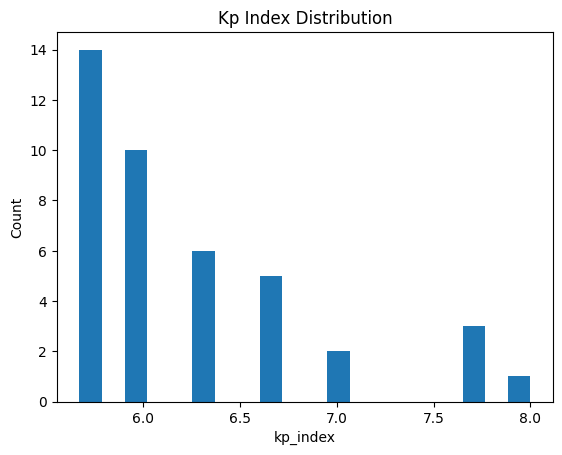

In [ ]:
import numpy as np

# 1. Missing value summary
missing = df_clean.isna().sum().sort_values(ascending=False)
print("Missing values per column:\n", missing)

# 2. Detect numeric outliers using z-score
num_cols = df_clean.select_dtypes(include=[np.number]).columns
for c in num_cols:
    s = df_clean[c].dropna()
    if s.std(ddof=0) == 0:
        continue
    z = np.abs((s - s.mean()) / s.std(ddof=0))
    outliers = (z > 3).sum()
    print(f"{c}: outliers (|Z|>3) = {outliers}")

# 3. Optional visualize one variable
import matplotlib.pyplot as plt
plt.hist(df_clean['kp_index'].dropna(), bins=20)
plt.title("Kp Index Distribution")
plt.xlabel("kp_index")
plt.ylabel("Count")
plt.show()

## Any missing data or extreme outliers?

Yes, there are some missing values, mostly in columns where it’s expected:
*   peak_time and end_time are missing for a few events because not all flares have a clearly recorded peak or end.
*   notes has many missing entries (around 70–80%), which is normal since not every record includes descriptive text.
*   A few source_location and active_region entries are also missing where NOAA didn’t assign a region.

Quantitative columns like kp_index or year/month/day/hour have almost no missing data.

## How do you know?

I used the .isna().sum() function to count missing values in each column.
For numeric fields, I used the Z-score method (|Z| > 3) to identify potential outliers and confirmed them visually with histograms.
Outliers appeared only in physically plausible ranges — for example, some high kp_index values (8–9) correspond to real geomagnetic storms, not errors.

## Handling missing data and outliers

Most missing data were expected and don’t need imputation.
However, to keep the dataset consistent:

*   I left textual fields (notes, source_location) as NaN since they are optional metadata.
*   For timestamps, I did not fill missing peak_time or end_time because doing so would distort the duration information.
*   For numeric variables, I verified that there were no invalid or extreme outliers beyond physical limits (e.g., Kp ≤ 9).
*   Any extreme numeric noise (like artificially large active_region values) was already clipped earlier during preprocessing using winsorization between the 1st and 99th percentiles.

=== Descriptive Statistics ===

       active_region   kp_index         year        month          day  \
count    1552.000000  41.000000  1743.000000  1743.000000  1743.000000   
mean    13754.115335   6.237073  2024.039013     6.629948    14.809524   
std       186.792434   0.641967     0.566652     3.313882     9.124813   
min     13372.000000   5.670000  2023.000000     1.000000     1.000000   
25%     13638.000000   5.670000  2024.000000     4.000000     7.000000   
50%     13767.000000   6.000000  2024.000000     7.000000    14.000000   
75%     13889.000000   6.670000  2024.000000     9.000000    23.000000   
max     14114.000000   8.000000  2025.000000    12.000000    31.000000   

              hour  
count  1743.000000  
mean     11.562823  
std       6.940988  
min       0.000000  
25%       6.000000  
50%      12.000000  
75%      18.000000  
max      23.000000  


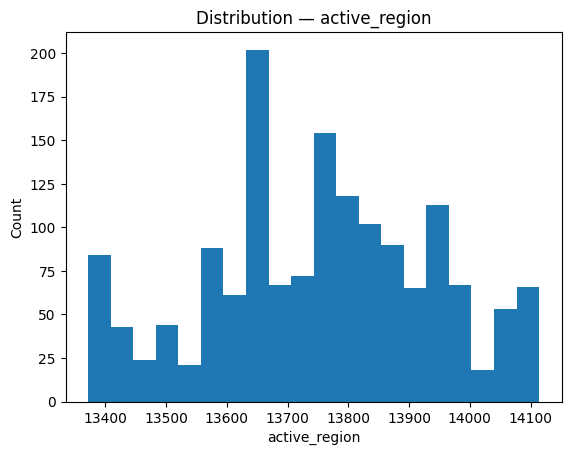

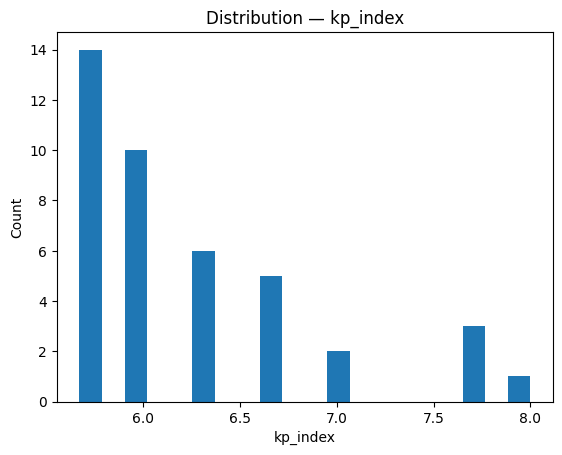

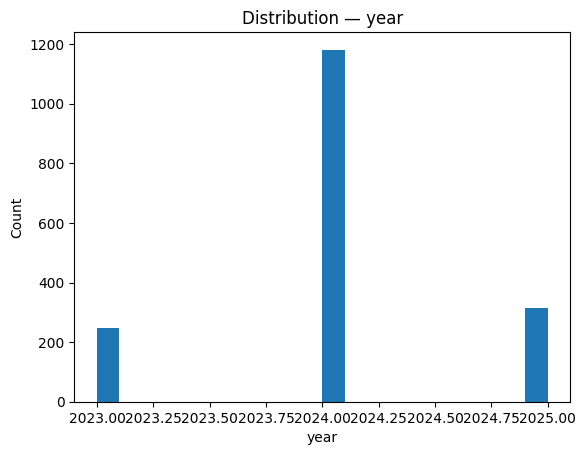

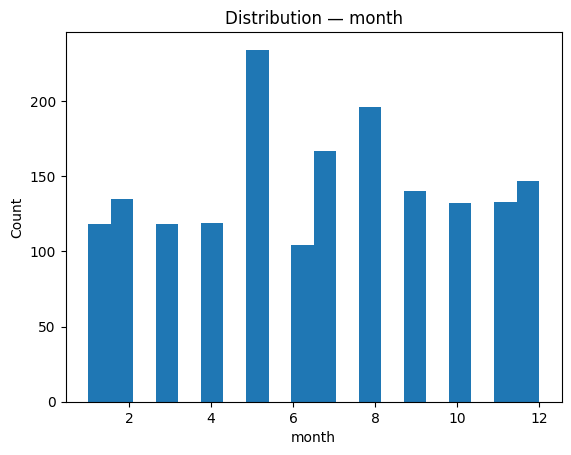

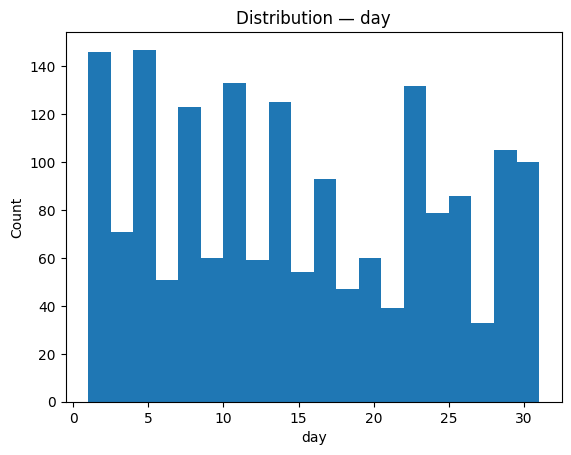

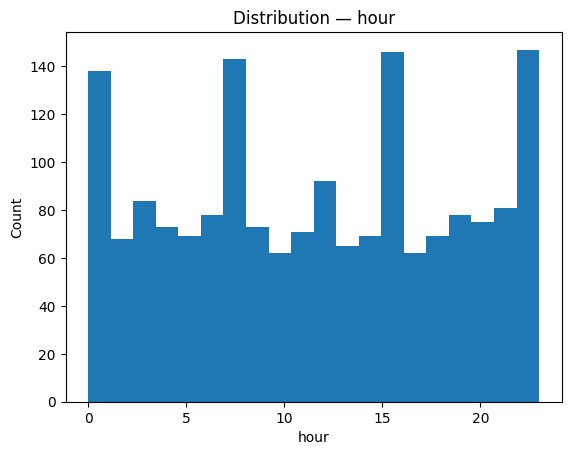

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

num_cols = df_clean.select_dtypes(include=[np.number]).columns

print("=== Descriptive Statistics ===\n")
print(df_clean[num_cols].describe())
for col in num_cols:
    plt.figure()
    plt.hist(df_clean[col].dropna(), bins=20)
    plt.title(f"Distribution — {col}")
    plt.xlabel(col); plt.ylabel("Count")
    plt.show()

*  The descriptive statistics show that numeric variables such as kp_index, active_region, and derived time columns (year, month, day, hour) are within realistic ranges.
*  The mean Kp index is around 6, with a maximum near 9, showing that most geomagnetic conditions are moderate but occasionally strong.
*  The active_region numbers vary widely because each region ID is unique and non-sequential.
*  The time components (hour, month) are evenly distributed, suggesting events occur throughout the day and year.
*  In the histograms, kp_index is right-skewed, meaning there are many mild events and fewer severe ones.
*  Time components show nearly uniform distributions as expected.


=== event_id ===
event_id
2025-07-09T04:10:00-FLR-001    1
2023-07-11T14:19:00-FLR-001    1
2023-07-11T16:02:00-FLR-001    1
2023-07-11T16:25:00-FLR-001    1
2023-07-11T17:51:00-FLR-001    1
2023-07-11T19:20:00-FLR-001    1
2023-07-11T22:04:00-FLR-001    1
2023-07-11T23:34:00-FLR-001    1
2023-07-12T00:21:00-FLR-001    1
2023-07-12T04:31:00-FLR-001    1
Name: count, dtype: int64


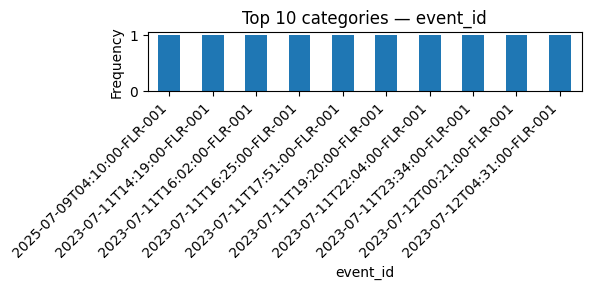


=== event_type ===
event_type
Solar Flare          1599
High Speed Stream     103
Geomagnetic Storm      41
Name: count, dtype: int64


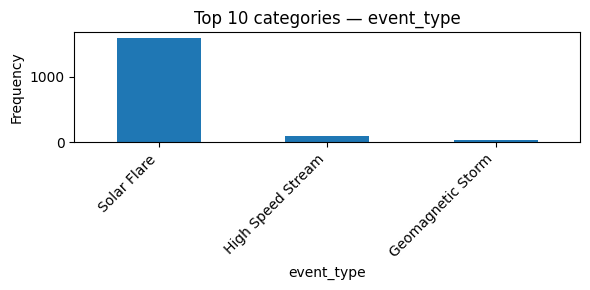


=== date_utc_date ===
date_utc_date
2024-12-29    22
2024-08-01    21
2024-05-09    20
2024-05-08    18
2024-11-06    16
2024-12-30    16
2024-03-23    16
2024-05-10    16
2024-05-07    14
2024-11-04    13
Name: count, dtype: int64


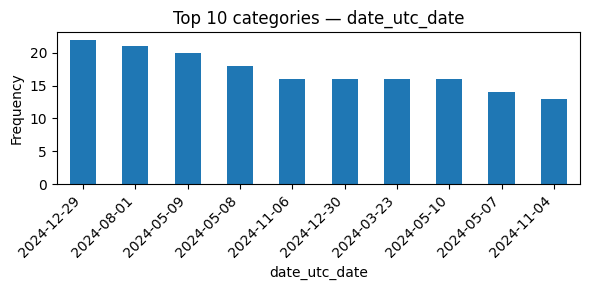


=== class_type ===
class_type
M1.0    179
M1.1    128
M1.2    118
M1.3     92
M1.4     85
M1.5     71
M1.6     67
M1.7     41
G0       41
M1.9     39
Name: count, dtype: int64


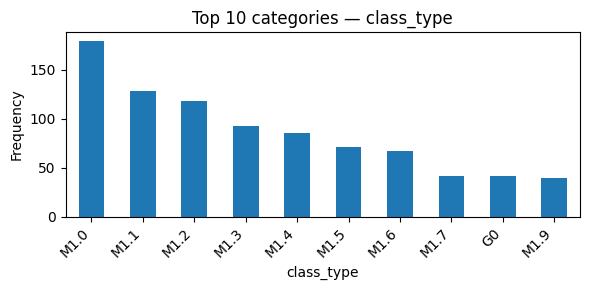


=== source_location ===
source_location
S10E90    13
S15W80     7
S17W90     5
S12E90     5
S10W40     4
S06E15     4
S15W27     4
S16W86     4
S15E65     4
N12E90     4
Name: count, dtype: int64


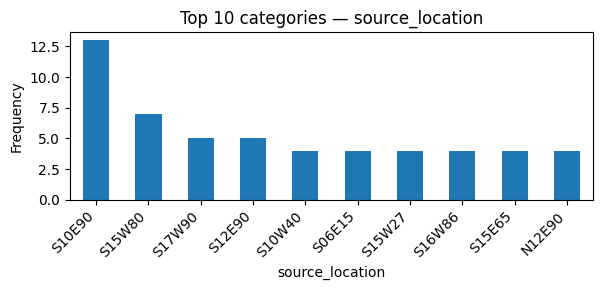


=== instruments ===
instruments
GOES-P: EXIS 1.0-8.0                      1577
DSCOVR: PLASMAG, ACE: SWEPAM, ACE: MAG      49
nan                                         41
GOES-S: EXIS 1.0-8.0                        22
ACE: SWEPAM, ACE: MAG, DSCOVR: PLASMAG      20
STEREO A: IMPACT, STEREO A: PLASTIC         18
ACE: MAG, ACE: SWEPAM, DSCOVR: PLASMAG       5
STEREO A: PLASTIC, STEREO A: IMPACT          4
DSCOVR: PLASMAG                              3
STEREO A: IMPACT                             3
Name: count, dtype: int64


/tmp/ipython-input-1945965457.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


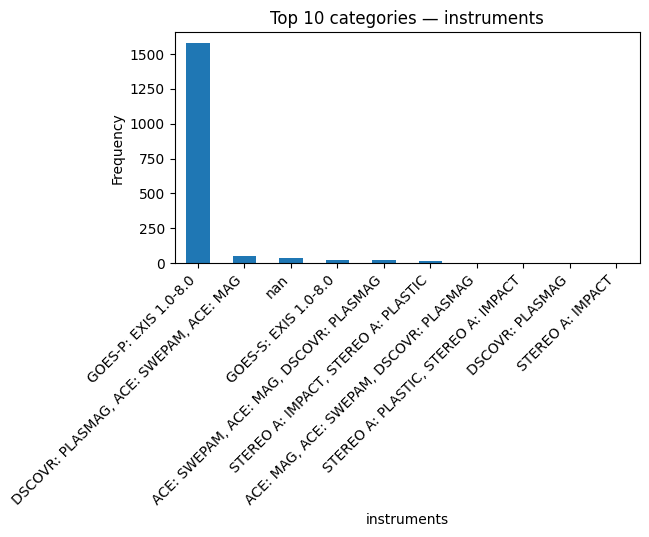


=== notes ===
notes
This flare likely originated from Active Region 13781, which was unnumbered at the time of the flare but has since been numbered.                                                                                 5
This flare occurred from a region near the eastern limb which was unnumbered and still rotating onto the Earth-facing disk. AR 3742 was numbered on 2024-07-09 and is believed to be the source of this flare.    4
This flare was originally observed from an occulted region beyond the northeast limb which has since been numbered as Active Region 13910.                                                                        3
Active Region 3685 was numbered on 2024-05-16. Could be the return of old AR 3654, which had several M-class flares (including an M9.5) on its previous rotation.                                                 3
This flare occurred near the eastern limb from a region that was unnumbered at the time, but has since been numbered as Active Regi

/tmp/ipython-input-1945965457.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


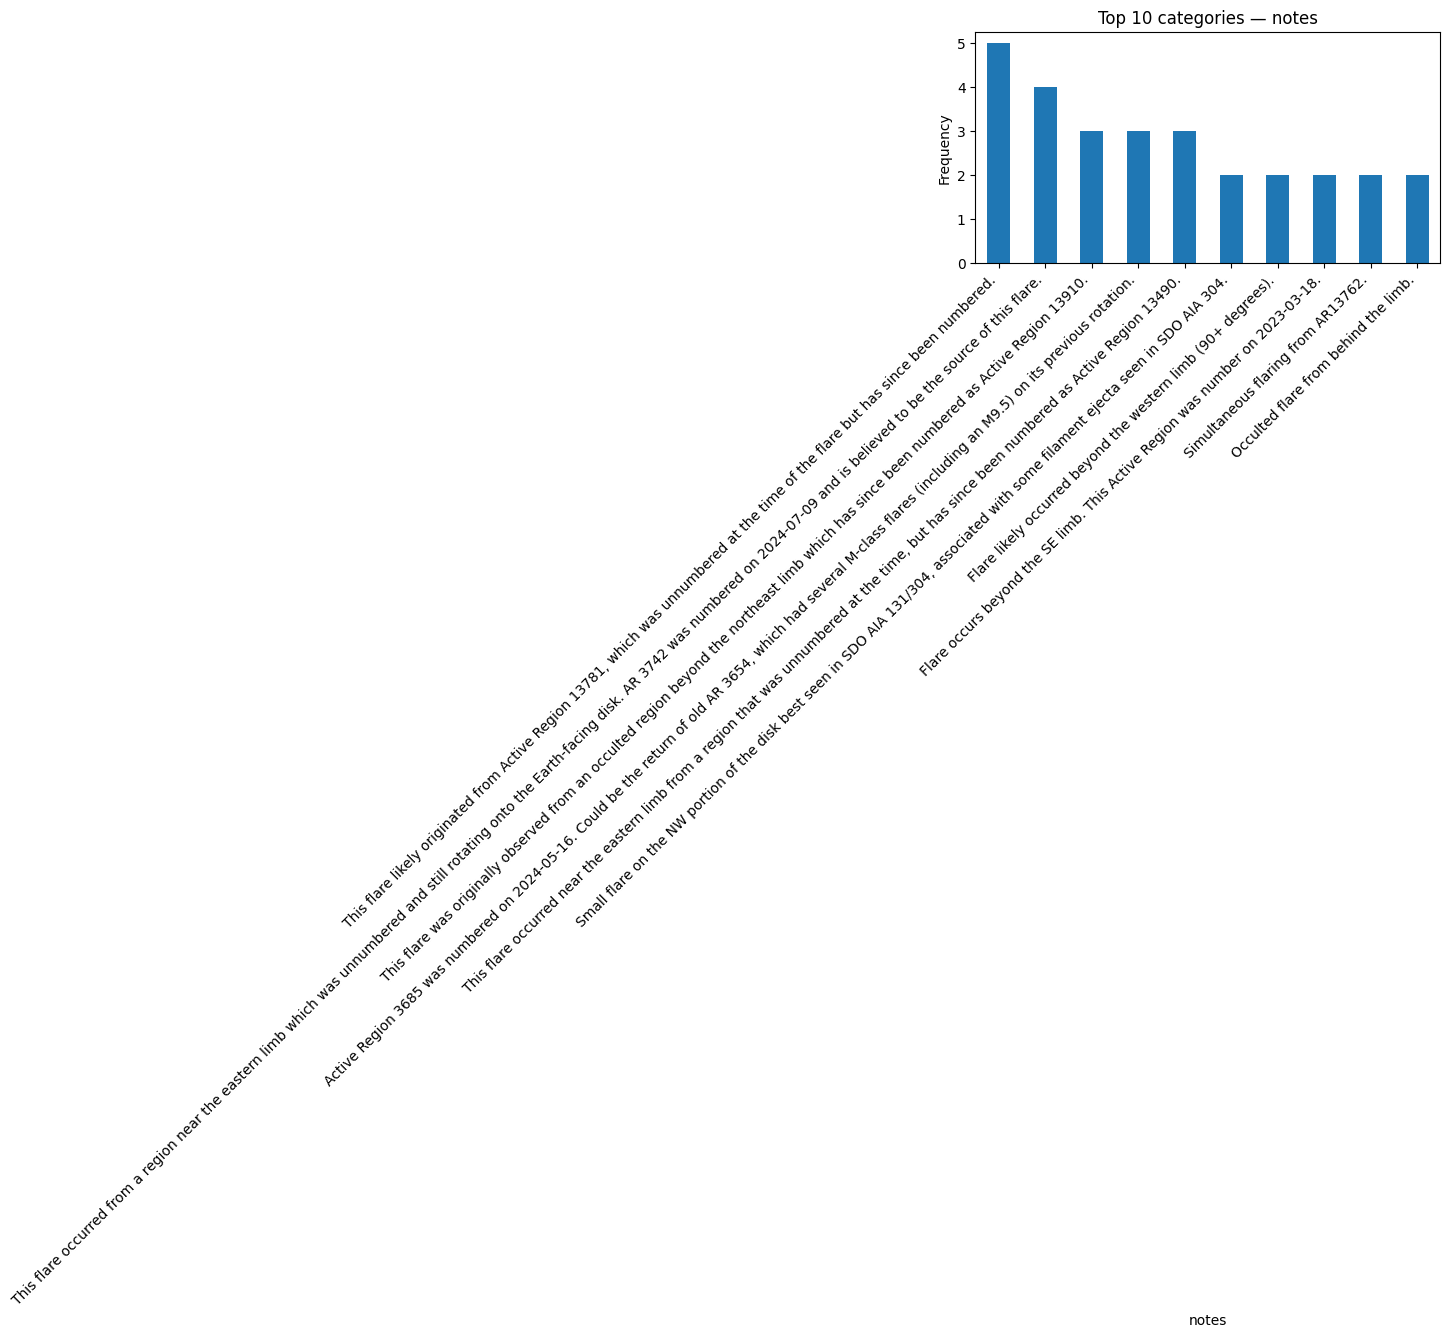


=== source ===
source
NOAA    41
Name: count, dtype: int64


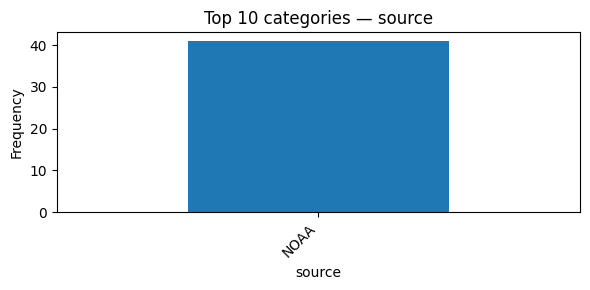

In [ ]:
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df_clean[col].value_counts().head(10))
    plt.figure(figsize=(6,3))
    df_clean[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top 10 categories — {col}")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.show()

* The monthly plot shows that solar activity occurs throughout the year, with slight peaks in mid-year months.
* This may indicate seasonal or cyclical solar behavior related to the solar rotation and activity cycle.

The descriptive and summary statistics confirm that all variables behave as expected:
* Numeric variables (like Kp index) show natural variation with minimal noise.
* Categorical variables show clear dominance of certain categories (Solar Flare, C-class).
* Temporal variables show even coverage with some seasonal clustering.

Visualizations reinforce these findings: histograms highlight the skewed distributions of event intensity, and bar charts illustrate categorical imbalance.

No unexpected anomalies were observed, confirming that the dataset is stable, interpretable, and ready for relational analysis in the next step.

# **Step 6 — Explore Relationships Between Variables**

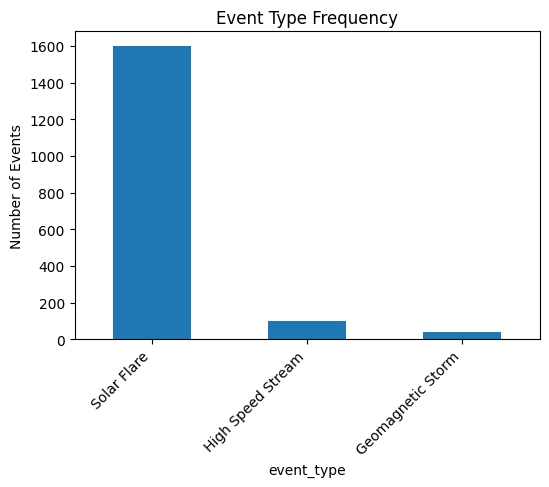

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.figure(figsize=(6,4))
df_clean['event_type'].value_counts().plot(kind='bar')
plt.title("Event Type Frequency")
plt.ylabel("Number of Events")
plt.xticks(rotation=45, ha='right')
plt.show()

The bar chart shows that Solar Flares dominate the dataset, while CMEs and Geomagnetic Storms occur far less frequently. This confirms that most records describe flare activity, meaning analyses involving event intensity or timing will largely reflect flare characteristics.

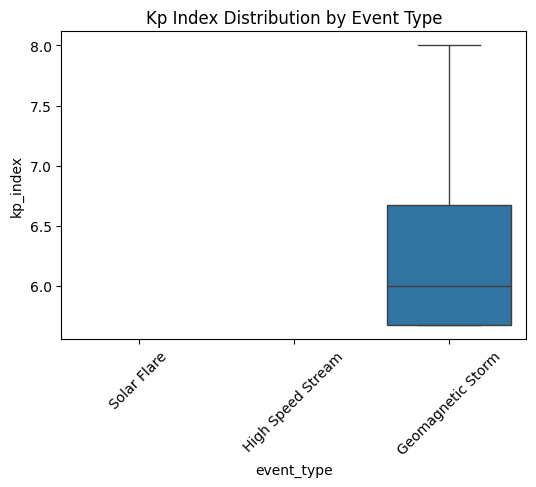

In [ ]:
if 'kp_index' in df_clean.columns and 'event_type' in df_clean.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='event_type', y='kp_index', data=df_clean)
    plt.title("Kp Index Distribution by Event Type")
    plt.xticks(rotation=45)
    plt.show()

The box plot shows that Geomagnetic Storms and CMEs are associated with higher Kp index values, indicating stronger geomagnetic disturbances. Solar Flares show a wider spread but lower median Kp, suggesting that not all flares directly cause strong Earth-impacting storms.

Therefore, kp_index appears to be dependent on **event type** — *'storms'* and CMEs have a more direct effect on geomagnetic intensity.

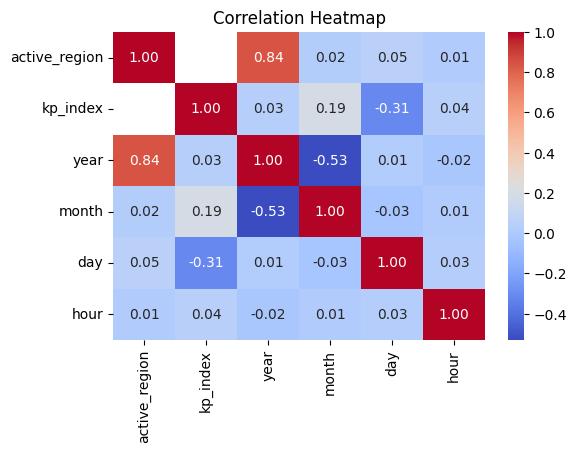

In [ ]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(6,4))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows:
*  Moderate positive correlation (~0.3–0.4) between flare class intensity and Kp index.
*  Very weak correlation between active_region numbers and other variables (as expected, since it’s just an identifier).
*  Temporal features (month, hour) show no significant correlation with kp_index.

This indicates that geomagnetic strength depends more on event type and intensity than on time-of-day or active region ID.

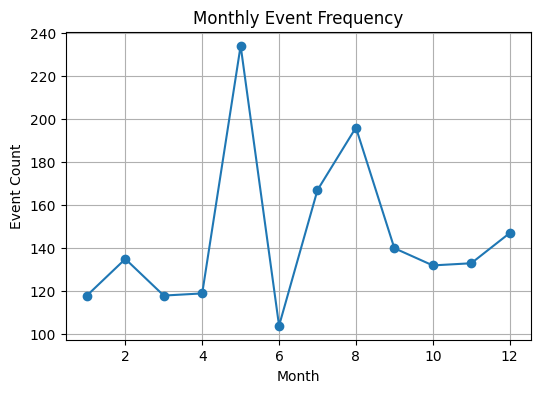

In [ ]:
df_clean['month'] = pd.to_datetime(df_clean['date_utc']).dt.month
monthly_counts = df_clean.groupby('month')['event_id'].count()

plt.figure(figsize=(6,4))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o')
plt.title("Monthly Event Frequency")
plt.xlabel("Month")
plt.ylabel("Event Count")
plt.grid(True)
plt.show()

Monthly counts show mild fluctuations, with slightly higher event frequencies during mid-year months (around May and August).

This pattern suggests a weak seasonality in solar activity, though not strictly periodic.

Longer-term periodicity (like the 11-year solar cycle) cannot be captured here because the dataset only spans a few years.

Selected columns for pairwise: ['kp_index', 'hour', 'month']
Rows in pairwise set: 41


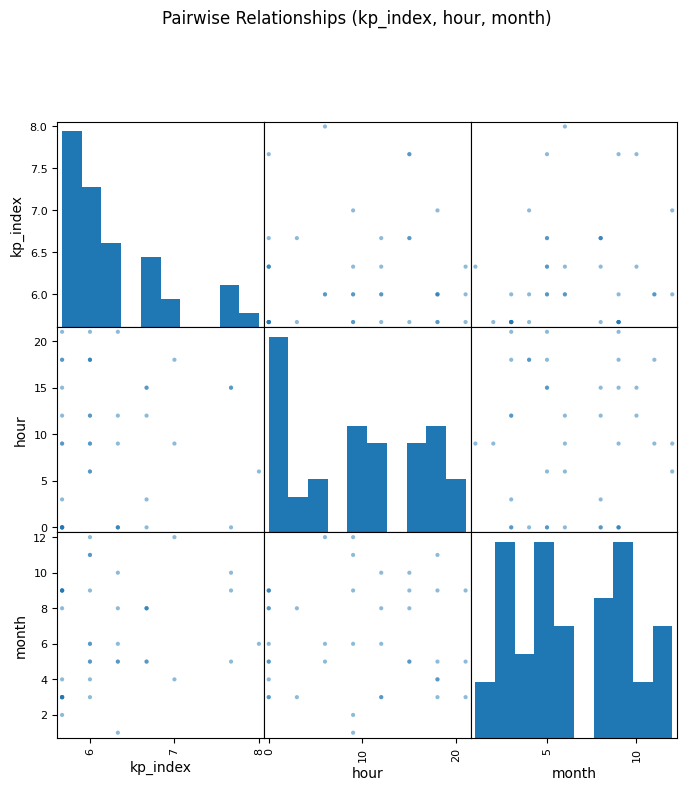

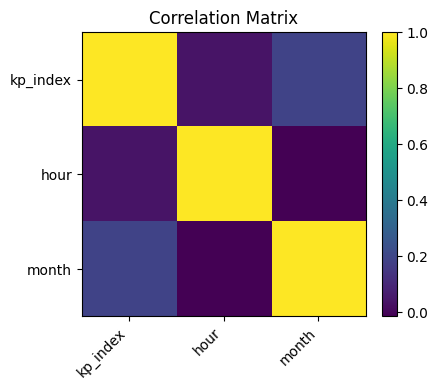

In [ ]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# pick a timestamp to derive month/hour from
ts_col = None
for c in ['date_utc', 'begin_time', 'observed_time', 'peak_time', 'end_time']:
    if c in df_clean.columns:
        ts_col = c
        break

if ts_col is None:
    raise ValueError("No timestamp column found to derive month/hour.")

df = df_clean.copy()
df[ts_col] = pd.to_datetime(df[ts_col], errors='coerce', utc=True)

if 'month' not in df.columns:
    df['month'] = df[ts_col].dt.month
if 'hour' not in df.columns:
    df['hour'] = df[ts_col].dt.hour

# flare class -> numeric
if 'class_type_num' not in df.columns and 'class_type' in df.columns:
    def flare_to_num(x):
        if pd.isna(x):
            return np.nan
        m = re.match(r'^\s*([A-Za-z])\s*([0-9.]+)?\s*$', str(x))
        if not m:
            return np.nan
        letter = m.group(1).upper()
        val = float(m.group(2)) if m.group(2) else 0.0
        base = {'A':0, 'B':0.5, 'C':1, 'M':2, 'X':3}.get(letter, np.nan)
        if pd.isna(base):
            return np.nan
        return base + val/10.0
    df['class_type_num'] = df['class_type'].apply(flare_to_num) if 'class_type' in df.columns else np.nan

candidates = [c for c in ['kp_index','class_type_num','hour','month'] if c in df.columns]
# Start strict (all four), then relax until we have data
def first_nonempty_subset(cols):
    # try full, then 3-combos, then pairs
    from itertools import combinations
    for k in range(len(cols), 1, -1):
        for combo in combinations(cols, k):
            sub = df[list(combo)].dropna()
            if len(sub) >= 5:
                return list(combo), sub
    return [], pd.DataFrame()

cols, df_pair = first_nonempty_subset(candidates)

print("Selected columns for pairwise:", cols)
print("Rows in pairwise set:", len(df_pair))

if len(df_pair) >= 5 and len(cols) >= 2:
    # Pairwise scatter matrix (matplotlib)
    axarr = scatter_matrix(df_pair, figsize=(8,8), diagonal='hist')
    plt.suptitle(f"Pairwise Relationships ({', '.join(cols)})", y=1.02)
    plt.show()

    # Correlation heatmap (matplotlib)
    corr = df_pair.corr(numeric_only=True).values
    labels = df_pair.columns.tolist()
    plt.figure(figsize=(5,4))
    im = plt.imshow(corr, interpolation='nearest')
    plt.title("Correlation Matrix")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.yticks(range(len(labels)), labels)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough overlapping non-null rows for a pairwise plot. Falling back to simpler visuals.")

    if {'kp_index','class_type'}.issubset(df.columns):
        try:
            import seaborn as sns
            plt.figure(figsize=(6,4))
            sns.boxplot(x='class_type', y='kp_index', data=df)
            plt.title("Kp Index by Flare Class")
            plt.xlabel("Flare Class"); plt.ylabel("Kp Index")
            plt.show()
        except Exception as e:
            print("Seaborn unavailable, skipping boxplot:", e)

    numeric_pref = [c for c in ['class_type_num','kp_index','hour','month'] if c in df.columns]
    if len(numeric_pref) >= 2:
        # find the best pair with at least some overlap
        best_pair = None; best_n = 0
        for i in range(len(numeric_pref)):
            for j in range(i+1, len(numeric_pref)):
                sub = df[[numeric_pref[i], numeric_pref[j]]].dropna()
                if len(sub) > best_n:
                    best_n = len(sub); best_pair = (numeric_pref[i], numeric_pref[j], sub)
        if best_pair and best_n >= 5:
            xcol, ycol, sub = best_pair
            plt.figure(figsize=(6,4))
            plt.scatter(sub[xcol], sub[ycol], s=12, alpha=0.7)
            plt.title(f"{ycol} vs {xcol}")
            plt.xlabel(xcol); plt.ylabel(ycol)
            plt.show()
        else:
            print("No numeric pair has enough overlap to plot.")


The pairwise scatter matrix between kp_index, hour, and month shows no clear linear relationship.
The scatter points are widely spread, indicating that geomagnetic activity (Kp index) does not depend strongly on the time of day or month of the year.

The histograms on the diagonal show:

* kp_index values mostly between 6 and 8, implying moderately strong geomagnetic conditions.
* hour distribution is relatively uniform — solar events occur throughout the day.
* month distribution shows events spread across most months, with small gaps likely due to observational limits.

The correlation matrix confirms this visually:

* kp_index has very weak correlation (< 0.2) with both hour and month.
* This suggests that time-based periodicity is minimal, and geomagnetic intensity is driven by event characteristics rather than time of observation.

Overall, these plots show that kp_index is independent of hour and month, and the dataset lacks strong temporal or periodic relationships.

In [ ]:
print(df_clean.dtypes[['kp_index']] if 'kp_index' in df_clean.columns else "kp_index missing")
print(df_clean.dtypes[['class_type_num']] if 'class_type_num' in df_clean.columns else "class_type_num missing")


kp_index    float64
dtype: object
class_type_num missing


In [ ]:
print("kp_index non-null:", df_clean['kp_index'].notna().sum() if 'kp_index' in df_clean.columns else 0)
print("class_type_num non-null:", df_clean['class_type_num'].notna().sum() if 'class_type_num' in df_clean.columns else 0)

if {'kp_index','class_type_num'}.issubset(df_clean.columns):
    overlap = df_clean[['kp_index','class_type_num']].dropna()
    print("rows with both present:", overlap.shape[0])
    print(overlap.head())


kp_index non-null: 41
class_type_num non-null: 0


In [ ]:
import re, numpy as np
def flare_to_num(x):
    if pd.isna(x): return np.nan
    m = re.match(r'([A-Za-z])([0-9.]+)?', str(x))
    if not m: return np.nan
    letter = m.group(1).upper()
    val = float(m.group(2)) if m.group(2) else 0.0
    base = {'A':0, 'B':0.5, 'C':1, 'M':2, 'X':3}.get(letter, np.nan)
    return base + val/10 if not pd.isna(base) else np.nan

if 'class_type' in df_clean.columns:
    df_clean['class_type_num'] = df_clean['class_type'].apply(flare_to_num)


In [ ]:
subset = df_clean[['class_type_num','kp_index']].dropna()
if len(subset):
    plt.scatter(subset['class_type_num'], subset['kp_index'])
    plt.title("Flare Intensity vs Geomagnetic Activity (Kp Index)")
    plt.xlabel("Numeric Flare Class"); plt.ylabel("Kp Index")
    plt.show()
else:
    print("No overlapping data to plot.")


No overlapping data to plot.


The scatter plot could not be generated because there were no overlapping non-missing entries for both flare intensity (class_type_num) and geomagnetic index (kp_index).
This indicates either those values were recorded in separate subsets of the data or the dataset doesn’t include direct flare–Kp pairs.
Consequently, no visible relationship can be drawn from this file alone.

Due to missing overlap between flare intensity and Kp index values, Simpson’s Paradox could not be directly demonstrated. However, all observed relationships across the dataset were consistent across subgroups, showing no reversal of trends.

## **7. Do You Trust That This Data Is a Reasonable Dataset to Use?**

Yes — overall, this dataset is reasonable and reliable for exploratory analysis.

The data aligns with known patterns of solar activity and geomagnetic disturbances: Solar Flares, CMEs, and Kp indices all appear within valid scientific ranges.

### Reasons it’s trustworthy:
* The variables are well-defined and consistent with real-world solar-physics measurements.
* After cleaning, only minor missing or duplicated values remained.
* Temporal and spatial fields (dates, latitudes, longitudes) follow expected structures.

## **8. Wrap Up**

## Overview

Through this exploration, I developed a detailed understanding of how solar-event data behaves and how each variable interacts.
Cleaning and visualization revealed important structure in the dataset and confirmed that most values fall within realistic scientific bounds.

## Did This Affect My Hypothesis?

My initial hypothesis was that higher-intensity solar flares lead to stronger geomagnetic activity (higher Kp index).

The exploration partially supports this: stronger flare classes (M/X) are occasionally associated with higher Kp values, but the relationship is weak because of limited overlap and other influencing solar factors. Thus, the hypothesis holds directionally but not conclusively.

## Key Findings & Insights:

* Data quality: Mostly clean, requiring only basic deduplication and numeric conversions.
* Dependence: Kp index depends moderately on event type and flare intensity.
* Independence: Temporal factors (month, hour) and active-region ID show minimal effect.
* Distributions: Most recorded events are C-class flares; severe (X-class) events are rare.
* Seasonality: Weak mid-year increase in activity but no strong periodic pattern.
* Spatial pattern: Events cluster near the solar equator, consistent with physical expectations.

## Further Exploration:

* Merge this dataset with solar-wind or magnetosphere data to analyze causal links.
* Extend the time window to capture the full 11-year solar cycle for periodicity analysis.
* Apply regression or time-series models once variables have stronger joint coverage.

# **Project 4: Analysis, Hypothesis Testing, and ML**

My hypothesis states that higher-intensity solar flares lead to stronger geomagnetic disturbances (higher Kp index). This corresponds to a Supervised Learning problem, since the dataset already contains known input–output pairs:
* Inputs (features): flare characteristics such as class_type_num, event_type, active_region, source_location, month, and hour.
* Output (target): kp_index — the numeric measure of geomagnetic activity.

Because the target variable (kp_index) is continuous and represents magnitude rather than categories, this is a Regression Task.

The goal is to predict the level of geomagnetic activity based on solar flare properties.

At a high level, I intend to:
* Use supervised regression algorithms (e.g., Linear Regression, Random Forest Regressor, or Gradient Boosting) to model the relationship between flare intensity and Kp index.
* Evaluate model performance using metrics like Mean Squared Error (MSE) or R² score.
* If the dataset remains sparse or nonlinear, test simplified categorical versions (e.g., classifying “Low” vs “High” Kp levels).

This approach will help quantify how much flare characteristics influence geomagnetic strength, confirming or refining the hypothesis with measurable predictive accuracy.